In [1]:
# DAY 34 - DESIGNING EXECUTIVE-LEVEL CUSTOMER DASHBOARDS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Day 34 libraries imported successfully!")

Day 34 libraries imported successfully!


In [2]:
# Load customer persona data

df = pd.read_csv("../Day31/customer_persona_summary.csv")

print("Customer data loaded successfully!")
print("Dataset shape:", df.shape)

print("\nAvailable columns:")
print(df.columns.tolist())

display(df.head())

Customer data loaded successfully!
Dataset shape: (2, 8)

Available columns:
['segment_name', 'Average Sales', 'Average Quantity', 'Average Profit', 'Average Discount', 'Average Shipping Days', 'Average Orders', 'Customer Count']


,segment_name,Average Sales,Average Quantity,Average Profit,Average Discount,Average Shipping Days,Average Orders,Customer Count
0,High-Value Customers,20109.22,267.53,2616.06,0.14,3.95,75.81,338
1,Regular Customers,12792.09,192.31,1279.66,0.15,3.99,56.16,457


In [4]:
# Check the actual customer data columns

print("Available columns in Day 34 dataset:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Available columns in Day 34 dataset:
['segment_name', 'Average Sales', 'Average Quantity', 'Average Profit', 'Average Discount', 'Average Shipping Days', 'Average Orders', 'Customer Count']

First 5 rows:


,segment_name,Average Sales,Average Quantity,Average Profit,Average Discount,Average Shipping Days,Average Orders,Customer Count
0,High-Value Customers,20109.22,267.53,2616.06,0.14,3.95,75.81,338
1,Regular Customers,12792.09,192.31,1279.66,0.15,3.99,56.16,457


In [5]:
# Load the original cleaned sales data for accurate KPI calculations

sales_df = pd.read_csv("../cleaned_dataset.csv")

print("Sales data loaded successfully!")
print("Sales dataset shape:", sales_df.shape)

print("\nColumns:")
print(sales_df.columns.tolist())

display(sales_df.head())


Sales data loaded successfully!
Sales dataset shape: (51290, 23)

Columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [6]:
# Calculate executive dashboard KPIs

total_customers = sales_df["customer_name"].nunique()
total_sales = sales_df["sales"].sum()
total_profit = sales_df["profit"].sum()
total_orders = sales_df["order_id"].nunique()

print("Executive KPI values calculated successfully!")

print("\nTotal Customers:", total_customers)
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)

Executive KPI values calculated successfully!

Total Customers: 795
Total Sales: 12642905.0
Total Profit: 1469034.82
Total Orders: 25035


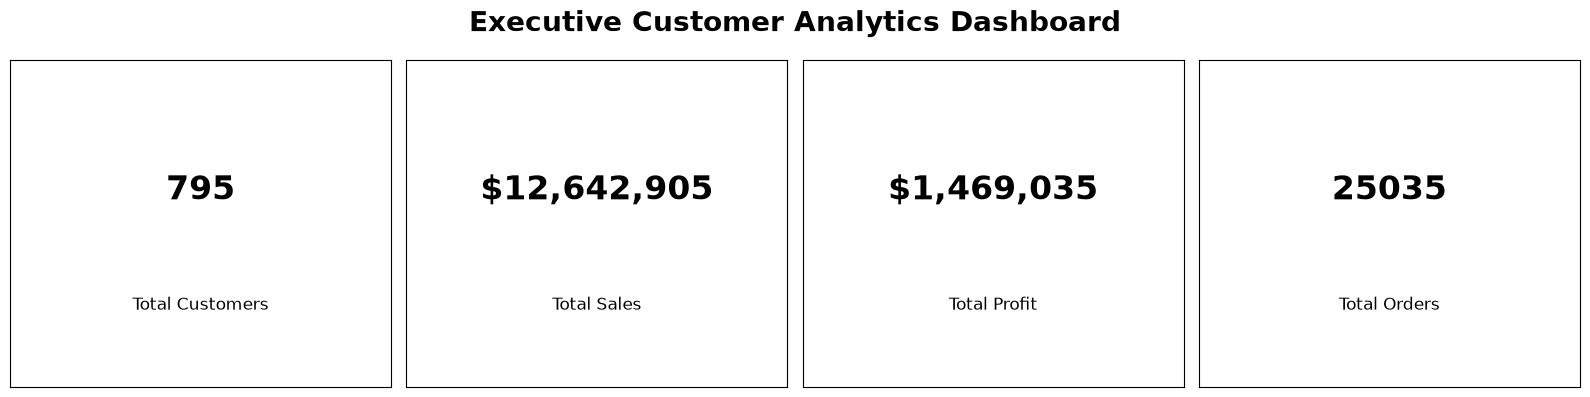

KPI cards created successfully!
Saved as: executive_kpi_cards.png


In [7]:
# Create executive KPI cards

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

kpis = [
    ("Total Customers", total_customers),
    ("Total Sales", f"${total_sales:,.0f}"),
    ("Total Profit", f"${total_profit:,.0f}"),
    ("Total Orders", total_orders)
]

for ax, (title, value) in zip(axes, kpis):
    ax.text(
        0.5, 0.6,
        str(value),
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold"
    )
    
    ax.text(
        0.5, 0.25,
        title,
        ha="center",
        va="center",
        fontsize=12
    )
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.suptitle(
    "Executive Customer Analytics Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

# Save dashboard KPI image
plt.savefig("executive_kpi_cards.png", dpi=150, bbox_inches="tight")

plt.show()

print("KPI cards created successfully!")
print("Saved as: executive_kpi_cards.png")

Customer segmentation data:


,segment_name,Customer Count
0,High-Value Customers,338
1,Regular Customers,457


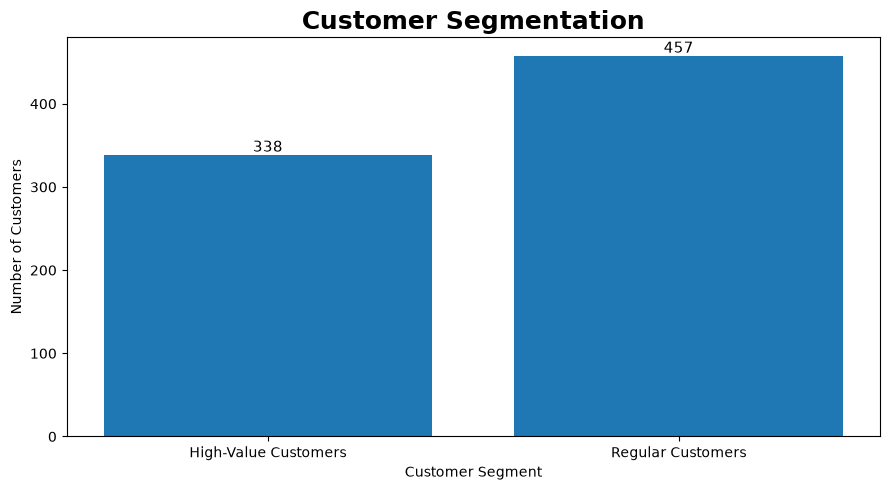

Customer segmentation chart created successfully!
Saved as: customer_segmentation.png


In [8]:
# Customer segmentation data

segment_counts = df[["segment_name", "Customer Count"]].copy()

print("Customer segmentation data:")
display(segment_counts)

# Create segmentation chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    segment_counts["segment_name"],
    segment_counts["Customer Count"]
)

plt.title(
    "Customer Segmentation",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

# Show values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "customer_segmentation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Customer segmentation chart created successfully!")
print("Saved as: customer_segmentation.png")

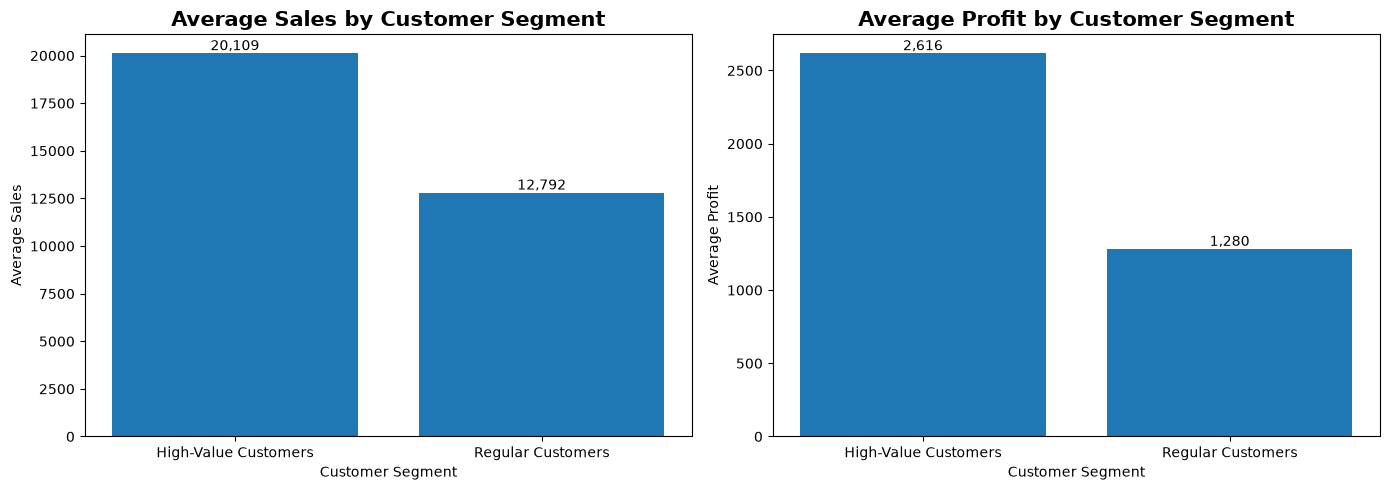

Segment comparison charts created successfully!
Saved as: segment_sales_profit_comparison.png


In [9]:
# Compare customer segments by average sales and profit

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average Sales
bars1 = axes[0].bar(
    df["segment_name"],
    df["Average Sales"]
)

axes[0].set_title(
    "Average Sales by Customer Segment",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Customer Segment")
axes[0].set_ylabel("Average Sales")

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

# Average Profit
bars2 = axes[1].bar(
    df["segment_name"],
    df["Average Profit"]
)

axes[1].set_title(
    "Average Profit by Customer Segment",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Customer Segment")
axes[1].set_ylabel("Average Profit")

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "segment_sales_profit_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Segment comparison charts created successfully!")
print("Saved as: segment_sales_profit_comparison.png")

In [11]:
# Load customer anomaly results from Day 33

anomaly_df = pd.read_csv("../Day33/customer_anomaly_results.csv")

print("Customer anomaly data loaded successfully!")
print("Dataset shape:", anomaly_df.shape)

print("\nColumns:")
print(anomaly_df.columns.tolist())

display(anomaly_df.head())

Customer anomaly data loaded successfully!
Dataset shape: (795, 9)

Columns:
['customer_name', 'total_sales', 'total_quantity', 'total_profit', 'average_discount', 'average_shipping_days', 'number_of_orders', 'anomaly', 'behavior_status']


,customer_name,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders,anomaly,behavior_status
0,Aaron Bergman,24646.0,301,4683.20800,0.110112,3.707865,89,1,Normal
1,Aaron Hawkins,20759.0,231,2450.92904,0.160929,3.464286,56,1,Normal
2,Aaron Smayling,14207.0,211,369.16180,0.167667,4.433333,60,1,Normal
3,Adam Bellavance,20189.0,262,4979.97690,0.131765,3.514706,68,1,Normal
4,Adam Hart,21720.0,293,1902.03342,0.093238,3.654762,84,1,Normal


In [12]:
# Count normal and anomalous customers

risk_counts = anomaly_df["behavior_status"].value_counts()

print("Customer behavior summary:")
print(risk_counts)

Customer behavior summary:
behavior_status
Normal       755
Anomalous     40
Name: count, dtype: int64


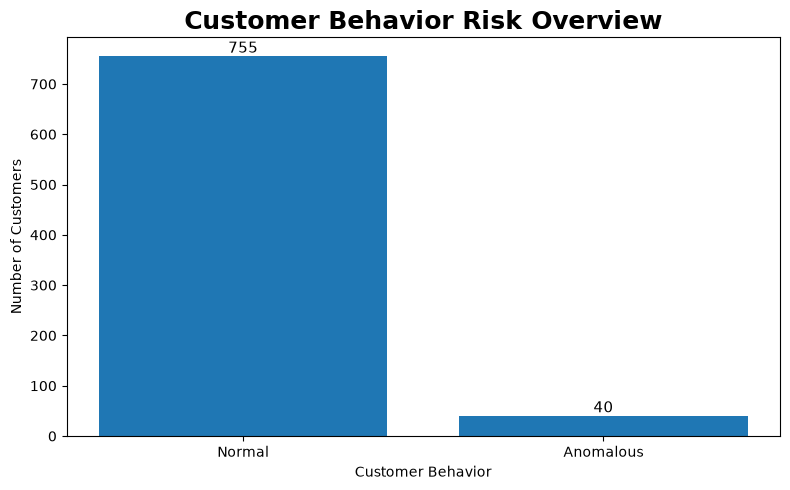

Customer risk chart created successfully!
Saved as: customer_risk_overview.png


In [13]:
# Create customer behavior risk chart

plt.figure(figsize=(8, 5))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title(
    "Customer Behavior Risk Overview",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Customer Behavior")
plt.ylabel("Number of Customers")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "customer_risk_overview.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Customer risk chart created successfully!")
print("Saved as: customer_risk_overview.png")

In [14]:
# Prepare monthly sales trend

sales_df["order_date"] = pd.to_datetime(sales_df["order_date"])

monthly_sales = (
    sales_df
    .groupby(sales_df["order_date"].dt.to_period("M"))["sales"]
    .sum()
    .reset_index()
)

monthly_sales["order_date"] = monthly_sales["order_date"].astype(str)

print("Monthly sales trend created successfully!")

display(monthly_sales.head())

Monthly sales trend created successfully!


,order_date,sales
0,2011-01,98902.0
1,2011-02,91152.0
2,2011-03,145726.0
3,2011-04,116927.0
4,2011-05,146762.0


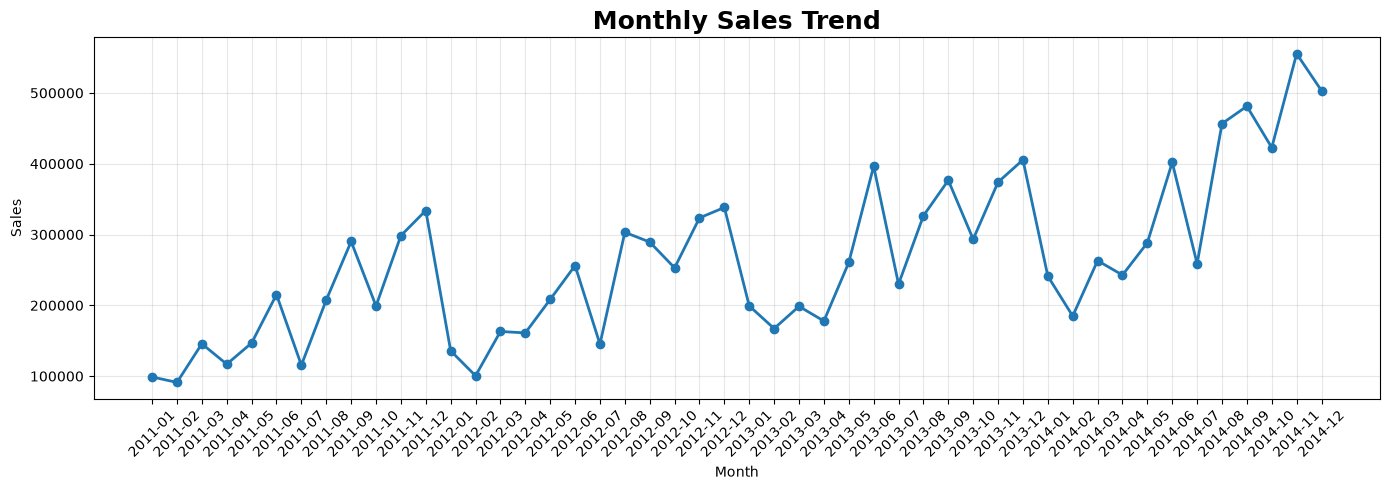

Monthly sales trend chart created successfully!
Saved as: monthly_sales_trend.png


In [15]:
# Create monthly sales trend chart

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["order_date"],
    monthly_sales["sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Sales Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "monthly_sales_trend.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Monthly sales trend chart created successfully!")
print("Saved as: monthly_sales_trend.png")

In [16]:
# Create customer activity / churn-risk proxy

customer_activity = (
    sales_df.groupby("customer_name")
    .agg(
        last_order_date=("order_date", "max"),
        number_of_orders=("order_id", "nunique"),
        total_sales=("sales", "sum")
    )
    .reset_index()
)

# Latest date available in the dataset
latest_date = sales_df["order_date"].max()

# Calculate days since last purchase
customer_activity["days_since_last_order"] = (
    latest_date - customer_activity["last_order_date"]
).dt.days

# Create activity risk categories
customer_activity["activity_risk"] = pd.cut(
    customer_activity["days_since_last_order"],
    bins=[-1, 30, 90, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("Customer activity risk analysis created successfully!")

display(customer_activity.head())

Customer activity risk analysis created successfully!


,customer_name,last_order_date,number_of_orders,total_sales,days_since_last_order,activity_risk
0,Aaron Bergman,2014-12-15,37,24646.0,16,Low Risk
1,Aaron Hawkins,2014-12-19,34,20759.0,12,Low Risk
2,Aaron Smayling,2014-12-08,31,14207.0,23,Low Risk
3,Adam Bellavance,2014-11-26,41,20189.0,35,Medium Risk
4,Adam Hart,2014-12-29,42,21720.0,2,Low Risk


Customer activity-risk summary:
activity_risk
Low Risk       589
Medium Risk    184
High Risk       22
Name: count, dtype: int64


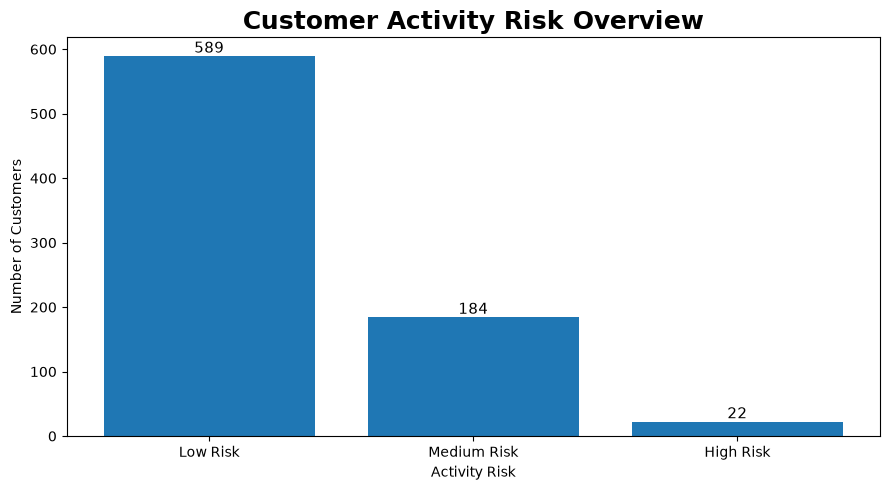

Customer activity-risk chart created successfully!
Saved as: customer_activity_risk.png


In [17]:
# Count customers in each activity-risk group

activity_risk_counts = (
    customer_activity["activity_risk"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .fillna(0)
)

print("Customer activity-risk summary:")
print(activity_risk_counts)

# Create chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    activity_risk_counts.index,
    activity_risk_counts.values
)

plt.title(
    "Customer Activity Risk Overview",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Activity Risk")
plt.ylabel("Number of Customers")

# Add values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "customer_activity_risk.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Customer activity-risk chart created successfully!")
print("Saved as: customer_activity_risk.png")

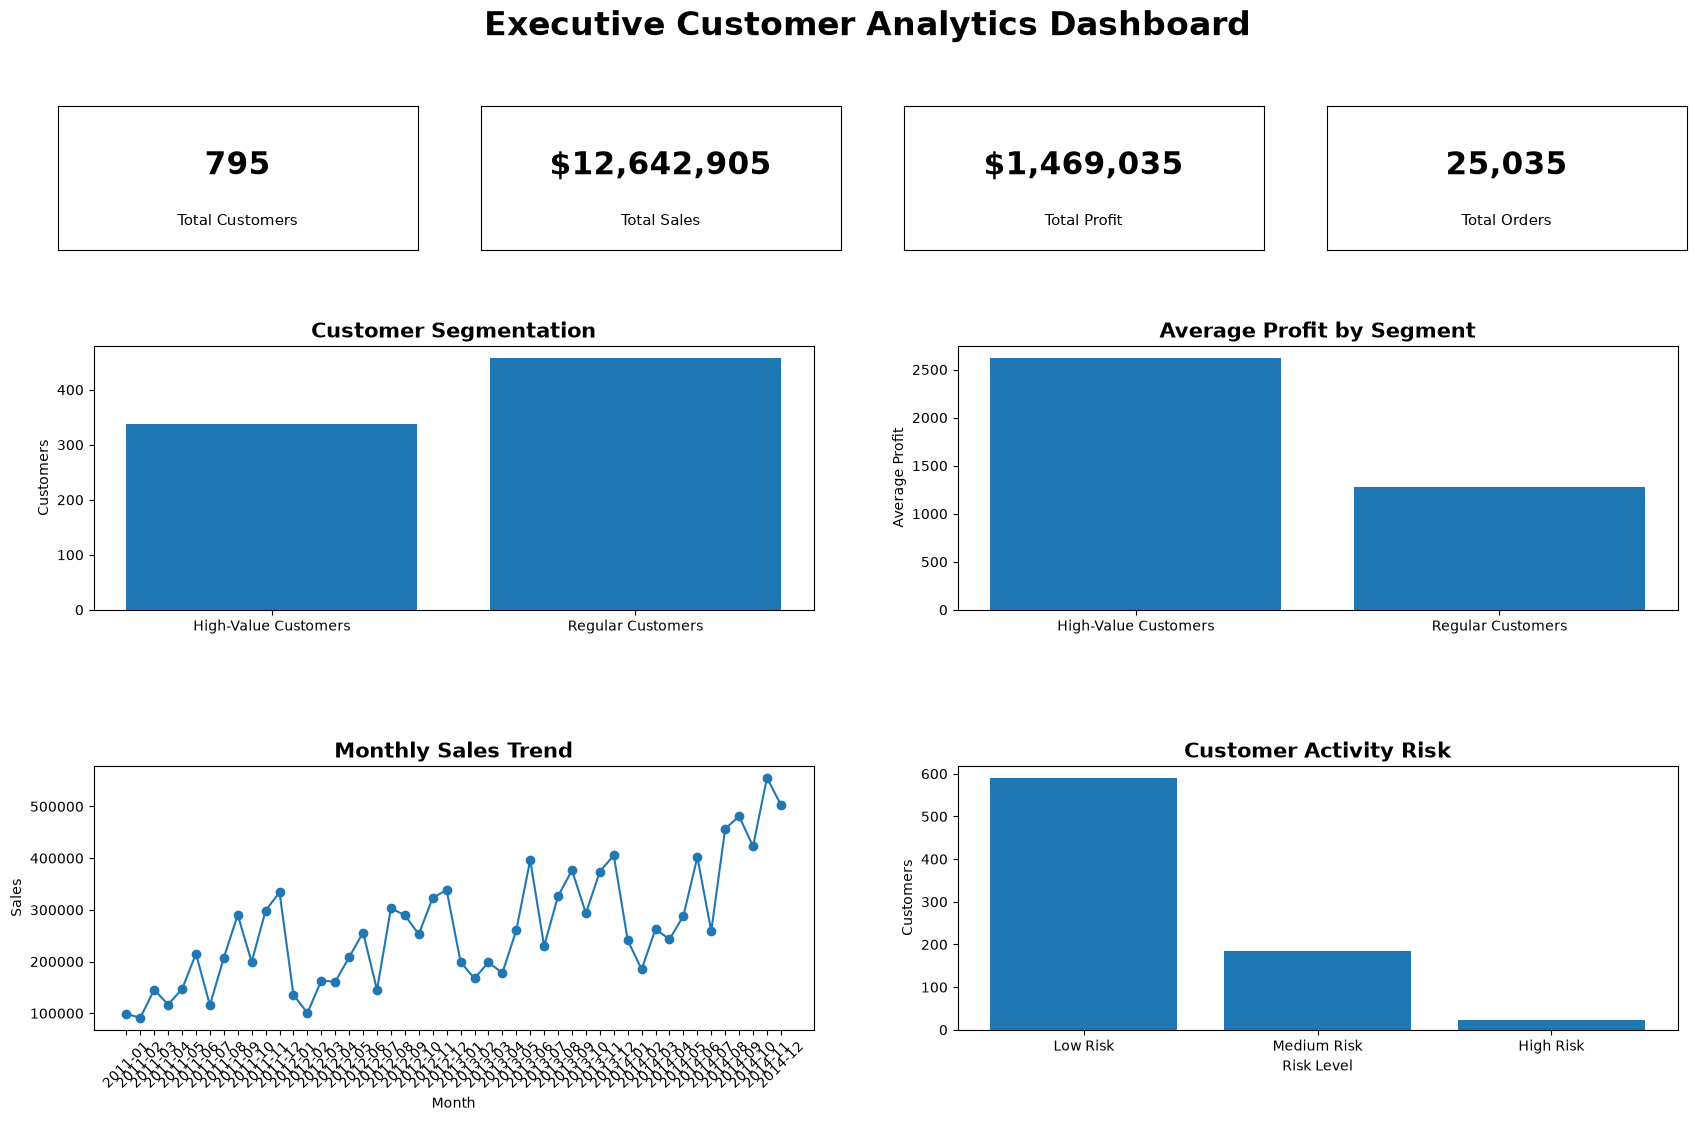

Executive dashboard created successfully!
Saved as: executive_customer_dashboard.png


In [18]:
# Create the complete executive customer dashboard

fig = plt.figure(figsize=(18, 12))

# -----------------------------
# 1. Dashboard title
# -----------------------------
fig.suptitle(
    "Executive Customer Analytics Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

# -----------------------------
# 2. KPI cards
# -----------------------------
kpi_data = [
    ("Total Customers", f"{total_customers:,}"),
    ("Total Sales", f"${total_sales:,.0f}"),
    ("Total Profit", f"${total_profit:,.0f}"),
    ("Total Orders", f"{total_orders:,}")
]

for i, (title, value) in enumerate(kpi_data):
    ax = fig.add_axes([
        0.05 + i * 0.235,
        0.78,
        0.20,
        0.12
    ])

    ax.text(
        0.5,
        0.58,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.20,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

# -----------------------------
# 3. Customer segmentation
# -----------------------------
ax1 = fig.add_axes([0.07, 0.48, 0.40, 0.22])

ax1.bar(
    df["segment_name"],
    df["Customer Count"]
)

ax1.set_title(
    "Customer Segmentation",
    fontsize=15,
    fontweight="bold"
)

ax1.set_ylabel("Customers")

# -----------------------------
# 4. Average profit
# -----------------------------
ax2 = fig.add_axes([0.55, 0.48, 0.40, 0.22])

ax2.bar(
    df["segment_name"],
    df["Average Profit"]
)

ax2.set_title(
    "Average Profit by Segment",
    fontsize=15,
    fontweight="bold"
)

ax2.set_ylabel("Average Profit")

# -----------------------------
# 5. Monthly sales trend
# -----------------------------
ax3 = fig.add_axes([0.07, 0.13, 0.40, 0.22])

ax3.plot(
    monthly_sales["order_date"],
    monthly_sales["sales"],
    marker="o"
)

ax3.set_title(
    "Monthly Sales Trend",
    fontsize=15,
    fontweight="bold"
)

ax3.set_xlabel("Month")
ax3.set_ylabel("Sales")
ax3.tick_params(axis="x", rotation=45)

# -----------------------------
# 6. Activity risk
# -----------------------------
ax4 = fig.add_axes([0.55, 0.13, 0.40, 0.22])

ax4.bar(
    activity_risk_counts.index,
    activity_risk_counts.values
)

ax4.set_title(
    "Customer Activity Risk",
    fontsize=15,
    fontweight="bold"
)

ax4.set_xlabel("Risk Level")
ax4.set_ylabel("Customers")

# -----------------------------
# Save dashboard
# -----------------------------
plt.savefig(
    "executive_customer_dashboard.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Executive dashboard created successfully!")
print("Saved as: executive_customer_dashboard.png")

In [19]:
# Generate key business insights for executives

high_value = df.loc[
    df["segment_name"] == "High-Value Customers"
].iloc[0]

regular = df.loc[
    df["segment_name"] == "Regular Customers"
].iloc[0]

high_value_sales = high_value["Average Sales"]
regular_sales = regular["Average Sales"]

high_value_profit = high_value["Average Profit"]
regular_profit = regular["Average Profit"]

high_value_customers = high_value["Customer Count"]
regular_customers = regular["Customer Count"]

print("KEY BUSINESS INSIGHTS")
print("=" * 50)

print(
    f"1. High-Value Customers: {int(high_value_customers)} customers"
)

print(
    f"2. Regular Customers: {int(regular_customers)} customers"
)

print(
    f"3. High-Value Customers have average sales of "
    f"{high_value_sales:,.2f}"
)

print(
    f"4. Regular Customers have average sales of "
    f"{regular_sales:,.2f}"
)

print(
    f"5. High-Value Customers have average profit of "
    f"{high_value_profit:,.2f}"
)

print(
    f"6. Regular Customers have average profit of "
    f"{regular_profit:,.2f}"
)

print(
    f"7. The dashboard also tracks monthly sales trends "
    f"and customer activity risk."
)

print(
    "8. Activity risk is a recency-based proxy and "
    "not a confirmed churn measurement."
)

print("\nBusiness insight generation completed successfully!")

KEY BUSINESS INSIGHTS
1. High-Value Customers: 338 customers
2. Regular Customers: 457 customers
3. High-Value Customers have average sales of 20,109.22
4. Regular Customers have average sales of 12,792.09
5. High-Value Customers have average profit of 2,616.06
6. Regular Customers have average profit of 1,279.66
7. The dashboard also tracks monthly sales trends and customer activity risk.
8. Activity risk is a recency-based proxy and not a confirmed churn measurement.

Business insight generation completed successfully!


In [20]:
# Create business insight summary

business_insights = f"""# Day 34 - Business Insight Summary

## Executive Customer Dashboard

### 1. Customer Segmentation

- High-Value Customers: {int(high_value_customers)}
- Regular Customers: {int(regular_customers)}

The dashboard separates customers into two segments based on their customer-level behavior and value.

### 2. Sales Performance

- High-Value Customers average sales: {high_value_sales:,.2f}
- Regular Customers average sales: {regular_sales:,.2f}

This comparison helps executives understand differences in customer value.

### 3. Profit Performance

- High-Value Customers average profit: {high_value_profit:,.2f}
- Regular Customers average profit: {regular_profit:,.2f}

Profit comparison provides an additional perspective beyond sales alone.

### 4. Sales Trend

Monthly sales trends are visualized to help decision-makers identify changes in business performance over time.

### 5. Customer Activity Risk

Customer activity risk is estimated using the number of days since the customer's most recent order.

The categories are:

- Low Risk
- Medium Risk
- High Risk

This is a recency-based activity-risk proxy and should not be interpreted as confirmed customer churn.

### 6. Dashboard Storytelling

The dashboard follows an executive-first structure:

1. KPI cards provide a quick business overview.
2. Customer segmentation shows the customer structure.
3. Profit comparison highlights customer value.
4. Sales trends show performance over time.
5. Activity risk highlights customers who may require further attention.

## Conclusion

The dashboard combines customer segmentation, financial performance, sales trends, and activity-risk indicators into a business-friendly executive view.
"""

with open("business_insight_summary.md", "w", encoding="utf-8") as file:
    file.write(business_insights)

print("Business insight summary created successfully!")
print("Saved as: business_insight_summary.md")

Business insight summary created successfully!
Saved as: business_insight_summary.md


In [21]:
# Check Day 34 output files

import os

files = [
    "day34.ipynb",
    "executive_kpi_cards.png",
    "customer_segmentation.png",
    "segment_sales_profit_comparison.png",
    "customer_risk_overview.png",
    "monthly_sales_trend.png",
    "customer_activity_risk.png",
    "executive_customer_dashboard.png",
    "business_insight_summary.md",
    "dashboard_storytelling.md",
    "README.md"
]

print("DAY 34 FILE CHECK")
print("=" * 40)

for file in files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

print("\nFile check completed!")

DAY 34 FILE CHECK
✓ day34.ipynb
✓ executive_kpi_cards.png
✓ customer_segmentation.png
✓ segment_sales_profit_comparison.png
✓ customer_risk_overview.png
✓ monthly_sales_trend.png
✓ customer_activity_risk.png
✓ executive_customer_dashboard.png
✓ business_insight_summary.md
✗ dashboard_storytelling.md
✓ README.md

File check completed!
